In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
%matplotlib inline
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

Fist of all I am downloading a custom data set I created from the galaxy zoo data on kaggle..
I did try to look for other easier ways to do this... like GalaxyMNIST (on github). It's supposed to work just like MNIST dataset (it basically extends MNIST), but the dropbox links the guy used in the repo were all dead (found that after hours of mental torture T-T) and the rest of the datasets he has created felt too complex or too large for my use...

Almost all the datasets i found on the internet are derived from the Galaxy Zoo or its successors like Galaxy Zoo 2, Zoo Hubble etc... I coudn't figure out how to get the original dataset from SDSS. Also,

https://www.zooniverse.org/projects/zookeeper/galaxy-zoo/

here it says, "27th May 2025: we have finished classifying galaxies in all the JWST:CEERS images."

I don't know where actually that is either. :')

The dataset I am using right now has only 3 classifications (Elliptical, spiral, and barred spiral) and only a small percentage of the images available in this dataset:
https://www.kaggle.com/datasets/robertmifsud/resized-reduced-gz2-images

I am planning to increase the no. of images once i have figured out the neural network, if I ever do...

Edit: I increased the no. of images. Specifically to 5000 training images and 1000 testing, per category. overall 18k images.


In [2]:
import requests
import zipfile
from pathlib import Path

# path where data gets stored
data_path = Path("data/")
image_path = data_path / "Galaxy_E_S_SB"
train_dir = image_path / "train"
test_dir = image_path / "test"

# If the image folder doesn't exist download it and prepare it
if image_path.is_dir():
  print(f"{image_path} directory already exists... skipping download")
else:
  print(f"{image_path} does not exist, creating one...")
  image_path.mkdir(parents=True, exist_ok=True)

  # Download the galaxy data
  with open(data_path / "Galaxy_E_S_SB.zip", 'wb') as f:
    request = requests.get("https://www.dropbox.com/scl/fi/ajsnxjlnm3b4w97mtmteo/Galaxy_E_S_SB.zip?rlkey=8vg29r735x3fslyhkyljtfb18&st=tbxu8e5l&dl=1")
    print("Downloading galaxy classification data...")
    f.write(request.content)
    f.close() ##
    # Unzip the data
    with zipfile.ZipFile(data_path / "Galaxy_E_S_SB.zip", "r") as zip_ref:
      print("Unzipping data...")
      zip_ref.extractall(image_path)



data/Galaxy_E_S_SB does not exist, creating one...
Unzipping data...


In [3]:
#device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

 ----
 About the dataset...

In [4]:
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f'There are {len(dirnames)} directories and {len(filenames)} images in "{dirpath}".')

walk_through_dir(image_path)


There are 2 directories and 0 images in "data/Galaxy_E_S_SB".
There are 3 directories and 0 images in "data/Galaxy_E_S_SB/train".
There are 0 directories and 8900 images in "data/Galaxy_E_S_SB/train/barred_spiral".
There are 0 directories and 8900 images in "data/Galaxy_E_S_SB/train/spiral".
There are 0 directories and 8900 images in "data/Galaxy_E_S_SB/train/elliptical".
There are 3 directories and 0 images in "data/Galaxy_E_S_SB/test".
There are 0 directories and 1000 images in "data/Galaxy_E_S_SB/test/barred_spiral".
There are 0 directories and 1000 images in "data/Galaxy_E_S_SB/test/spiral".
There are 0 directories and 1000 images in "data/Galaxy_E_S_SB/test/elliptical".


Random image path: data/Galaxy_E_S_SB/train/elliptical/122510.jpg


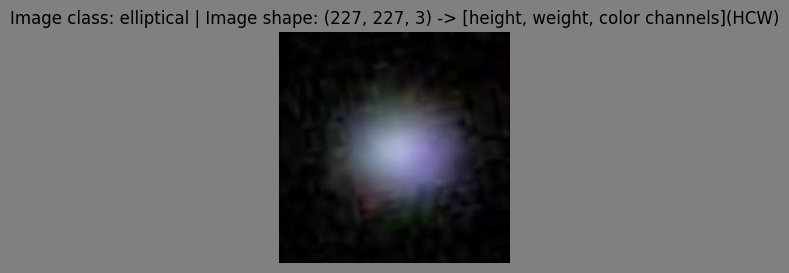

In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image


""" Creating a list of image paths , selecting a random image and displaying it"""

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)

img_as_array = np.asarray(img)
plt.figure(figsize=(3, 3)).set_facecolor('grey')
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, weight, color channels](HCW)")
"""Pytorch uses CHW instead of HCW"""
plt.axis(False)
print(f"Random image path: {random_image_path}")



array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [2, 2, 2],
        [2, 2, 2],
        [2, 2, 2]],

       ...,

       [[5, 5, 5],
        [4, 4, 4],
        [2, 2, 2],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[5, 5, 5],
        [4, 4, 4],
        [2, 2, 2],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[5, 5, 5],
        [4, 4, 4],
        [2, 2, 2],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
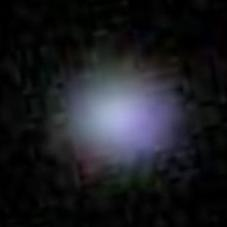

In [6]:
img_as_array

--------------------
Now to transform our image data into a form which can be used by pytorch, i.e. tensors (plus resizing and stuff), and to turn it into a 'torch.utils.data.Dataset' so that we can load it with 'DataLoader'

In [7]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

data_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)), #change this to (224, 224) in case you think model could learn better that way
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    # transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])


In [8]:
data_transform(img).shape

torch.Size([3, 224, 224])

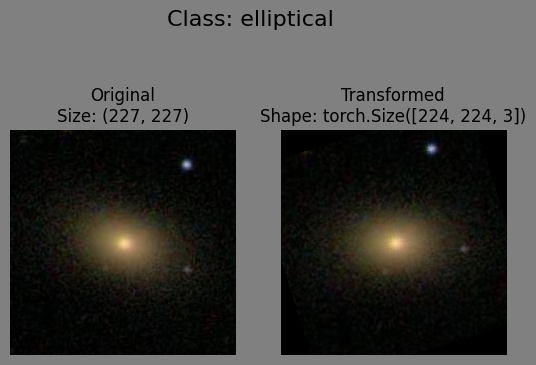

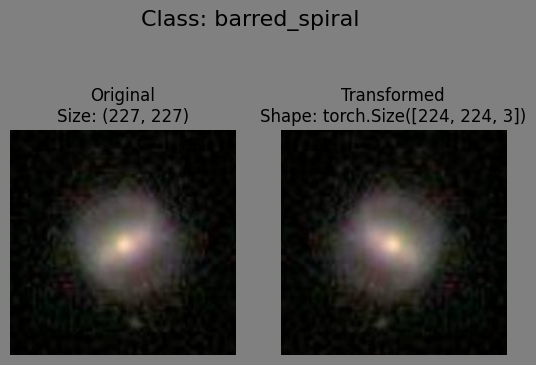

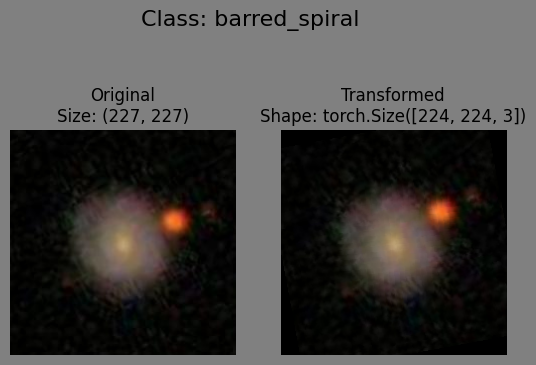

In [9]:
def plot_transformed_images(image_paths: list, transform, n=3, seed=None):
  """Plots random original vs transformed imgaes"""
  if(seed):
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with(Image.open(image_path)) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)
      transformed_img = transform(f).permute(1, 2, 0) # CHW to HWC
      ax[1].imshow(transformed_img)
      ax[1].set_title(f"Transformed\nShape: {transformed_img.shape}")
      ax[1].axis(False)
      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)
      fig.set_facecolor('grey')


plot_transformed_images(image_paths=image_path_list, transform=data_transform,
                        n=3, seed=42)


------------
Since our data is in standard image classification format, we can use torchvision.datasets.**ImageFolder** to load our image data...
https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html

In [10]:
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, # tranform for our image data
                                  target_transform=None) # transform for our targets/labels(we don't have any here, they are usually in csv format or smthg. Here we get our labels from the parent directory of the image)

test_data = datasets.ImageFolder(root=test_dir,
                                  transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 26700
     Root location: data/Galaxy_E_S_SB/train
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 3000
     Root location: data/Galaxy_E_S_SB/test
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
                ToTensor()
            ))

In [11]:
# Get class name as a list
class_names = train_data.classes
class_names

['barred_spiral', 'elliptical', 'spiral']

In [12]:
# Get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'barred_spiral': 0, 'elliptical': 1, 'spiral': 2}

In [13]:
from torch.utils.data import dataloader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count() #its the no. of cpu cores. to maximize set as os.cpu_count()

train_DataLoader =  DataLoader(dataset = train_data,
                               batch_size = BATCH_SIZE,
                               num_workers = NUM_WORKERS,
                               shuffle = True)

test_DataLoader =  DataLoader(dataset = test_data,
                              batch_size = BATCH_SIZE,
                              num_workers = NUM_WORKERS,
                              shuffle = True)



In [14]:
NUM_WORKERS

2

------
Finally we start building the model!! Now this is going to be a Convolutional Neural Network and we have lot options on what kind it is going to be and how we choose to customize it (the number/types of layers, values of hyperparameters etc.)... I'll do hit and trials and try to find out which one works best...
This one is based on TinyVGG (from CNN explainer website)
https://poloclub.github.io/cnn-explainer/


In [15]:
# Create a convolutinal neural network
class GalaxyClass(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        # A block is comprised of multiple layers, and an overall architecture of multiple blocks
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1, #Hyperparameters-> values we can set
                  padding=1),
        nn.ReLU(),

        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        # nn.BatchNorm2d(hidden_units),
        # nn.Dropout2d(p=0.2),# to prevent overfitting we dropout some neurons (set them as 0)
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),

        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.BatchNorm2d(hidden_units),
        nn.Dropout2d(p=0.2),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.conv_block_3 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),

        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        # nn.BatchNorm2d(hidden_units),
        # nn.Dropout2d(p=0.2),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*28*28,
                  #setting this as hidden_units is most probably wrong.
                  #the shape of the output of the previous layers should be
                  #compatible with this linear layer for matrix multiplication. We
                  #can either calculate this specific number by using the formula in the
                  #pytorch documentary or, run a sample batch through the model and
                  #look at the error for some hint.
                  #
                  out_features=512),# this is completely arbitrary
        nn.Dropout(p=0.5),
        nn.ReLU(),
        nn.Linear(in_features=512,#this should be same as out_features of previous layer
                  out_features=output_shape),
        # nn.Softmax(dim=1) # Okay this was wrong.. CrossEntropy loss takes logits as inputs not softmax outputs

    )

  def forward(self, x):
  #   x = self.conv_block_1(x)
  #  # print(x.shape)
  #   x = self.conv_block_2(x)
  #  # print(x.shape)
  #   x = self.classifier(x)
  #  # print(x.shape)
  #   return x

    return self.classifier(self.conv_block_3(self.conv_block_2(self.conv_block_1(x))))
    # this is operator fusion and helps in faster computation



In [16]:
# torch.manual_seed(42)
model = GalaxyClass(input_shape = 3, #no. of color channels (RGB)
                    hidden_units = 32, # this can be anything
                    output_shape = len(class_names)).to(device)
model

GalaxyClass(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Dropout2d(p=0.2, inplace=False)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, pa

In [17]:
# Try a forward pass on a single image batch
image_batch, label_batch = next(iter(train_DataLoader))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [18]:
model(image_batch.to(device)) # model is on device (gpu) so the image batch has to sent to the device too

# Now here this should raise an error if the in_features parameter
# in the linear layer of classifier block of the model is wrong...
# Just change it to whatever the correct value is and it should work...


tensor([[-0.0344,  0.0153, -0.0684],
        [ 0.0202, -0.0264, -0.0796],
        [ 0.0023, -0.0787, -0.0224],
        [ 0.0393, -0.0195, -0.0371],
        [-0.0111, -0.0535, -0.0970],
        [ 0.0325, -0.0247, -0.0948],
        [-0.0286, -0.0106, -0.0276],
        [-0.0405, -0.0136, -0.0924],
        [-0.0500, -0.0718, -0.0493],
        [-0.0188, -0.0241, -0.0424],
        [-0.0092, -0.0782, -0.0258],
        [-0.0271, -0.0358, -0.0690],
        [ 0.0140, -0.0366, -0.0140],
        [-0.0023, -0.0292, -0.0522],
        [-0.0075, -0.0460, -0.0666],
        [ 0.0566, -0.0523,  0.0008],
        [ 0.0445, -0.0164, -0.0041],
        [-0.0054, -0.0179, -0.0472],
        [ 0.0300,  0.0303, -0.0446],
        [-0.0088, -0.0725, -0.0632],
        [ 0.0072, -0.0083, -0.0374],
        [ 0.0336, -0.0207, -0.0263],
        [-0.0136, -0.0175, -0.0703],
        [ 0.0547, -0.0395, -0.0244],
        [-0.0077, -0.0060, -0.0418],
        [-0.0137,  0.0340, -0.0628],
        [ 0.0290, -0.0065, -0.0178],
 

In [19]:
# Install torchinfo, import if it's available
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224)) # (BatchSize, C, H, W)

Layer (type:depth-idx)                   Output Shape              Param #
GalaxyClass                              [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         896
│    └─ReLU: 2-2                         [1, 32, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 32, 224, 224]         9,248
│    └─ReLU: 2-4                         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 32, 56, 56]           --
│    └─Conv2d: 2-6                       [1, 32, 112, 112]         9,248
│    └─ReLU: 2-7                         [1, 32, 112, 112]         --
│    └─Conv2d: 2-8                       [1, 32, 112, 112]         9,248
│    └─BatchNorm2d: 2-9                  [1, 32, 112, 112]         64
│    └─Dropout2d: 2-10                   [1, 32, 112, 112]         --
│    

In [20]:

optimizer = optim.Adam(model.parameters(), lr=0.0004)
loss_fn = nn.CrossEntropyLoss()


def train():
  model.train()
  train_loss, train_acc = 0, 0

  for batch_idx, (data, target) in enumerate(train_DataLoader):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = loss_fn(output, target)
    train_loss += loss.item()
    loss.backward()
    optimizer.step()
    pred = output.argmax(dim=1)
    train_acc += (pred==target).sum().item() / len(pred)

  # calculating average train loss and accuracy per batch
  train_loss /= len(train_DataLoader)
  train_acc /= len(train_DataLoader)
  return train_loss, train_acc


all_preds = []
all_targets = []

def test():
  model.eval()
  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    # ok so the documentation says that this is analogous to torch.no_grad(),
    # (with a couple of extra features?). i don't exactly know how this and torch.no_grad() are different,
    # but since this is the newer one i'll just assume this is better. :)
    for data, target in test_DataLoader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      loss = loss_fn(output, target)
      test_loss += loss.item()
      pred = output.argmax(dim=1)

      all_preds.extend(pred.cpu().numpy())
      all_targets.extend(target.cpu().numpy())

      test_acc += (pred==target).sum().item() / len(pred)

    # calculating average test loss and accuracy per batch
    test_loss /= len(test_DataLoader)
    test_acc /= len(test_DataLoader)
  return test_loss, test_acc



  0%|          | 0/40 [00:00<?, ?it/s]


Epoch: 1
---------
Train loss: 0.9397, Train accuracy: 54.0968%

Test loss: 0.9363, Test accuracy: 55.1086%

[[456 431 113]
 [ 31 927  42]
 [315 414 271]]


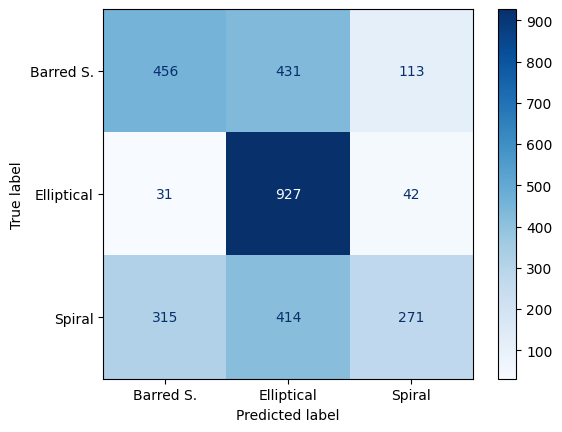


Epoch: 2
---------
Train loss: 0.8839, Train accuracy: 58.0689%

Test loss: 0.8794, Test accuracy: 57.1254%

[[575 342  83]
 [ 47 935  18]
 [406 389 205]]


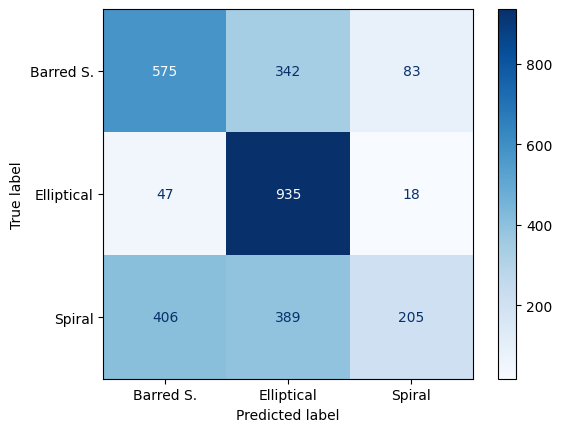


Epoch: 3
---------
Train loss: 0.8328, Train accuracy: 61.2537%

Test loss: 0.8039, Test accuracy: 62.5332%

[[590 126 284]
 [104 764 132]
 [290 188 522]]


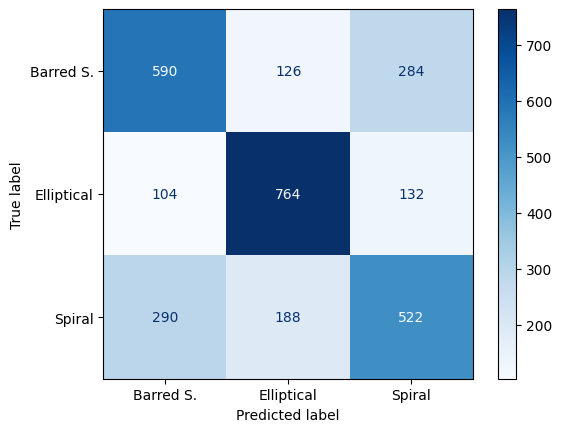


Epoch: 4
---------
Train loss: 0.7811, Train accuracy: 64.3126%

Test loss: 0.7798, Test accuracy: 64.5279%

[[776  88 136]
 [147 721 132]
 [419 142 439]]


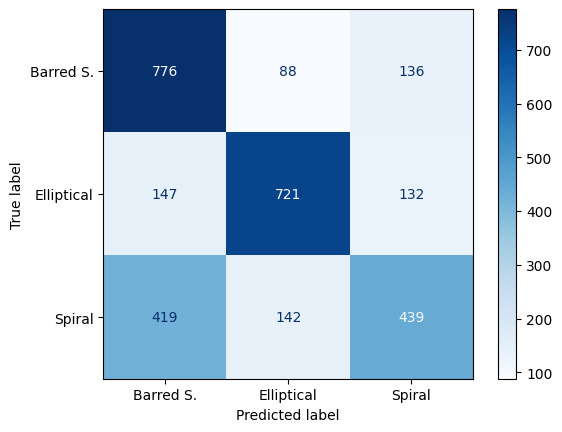


Epoch: 5
---------
Train loss: 0.7205, Train accuracy: 68.0714%

Test loss: 0.6946, Test accuracy: 69.1046%

[[772 163  65]
 [ 48 922  30]
 [336 285 379]]


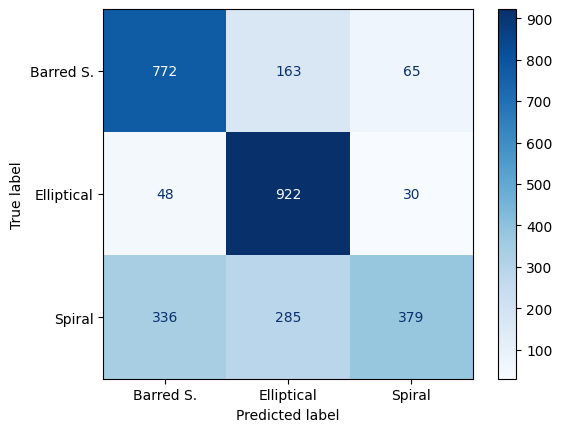


Epoch: 6
---------
Train loss: 0.6806, Train accuracy: 70.0811%

Test loss: 0.6369, Test accuracy: 72.3293%

[[692 144 164]
 [ 28 908  64]
 [173 258 569]]


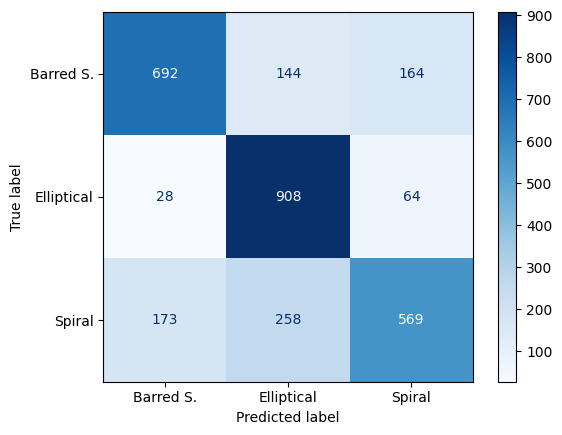


Epoch: 7
---------
Train loss: 0.6570, Train accuracy: 71.4908%

Test loss: 0.6219, Test accuracy: 73.3932%

[[721 113 166]
 [ 40 840 120]
 [167 193 640]]


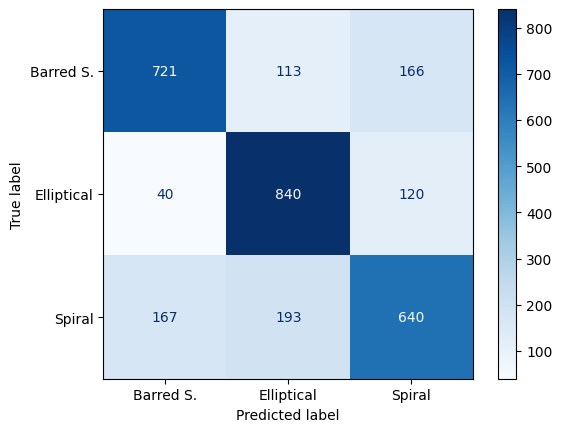


Epoch: 8
---------
Train loss: 0.6378, Train accuracy: 72.5848%

Test loss: 0.6628, Test accuracy: 70.1241%

[[765 182  53]
 [ 29 949  22]
 [308 303 389]]


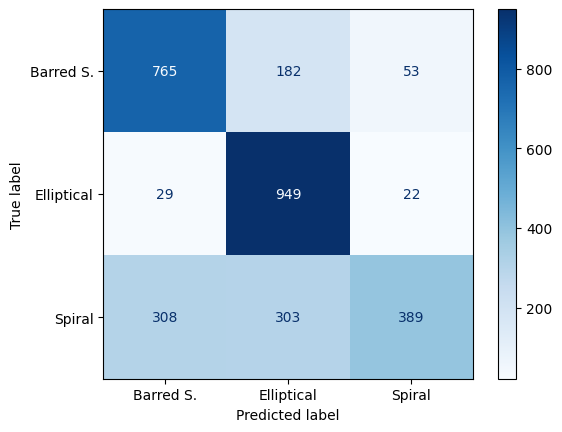


Epoch: 9
---------
Train loss: 0.6271, Train accuracy: 72.9479%

Test loss: 0.6194, Test accuracy: 73.3932%

[[659 170 171]
 [ 12 948  40]
 [100 307 593]]


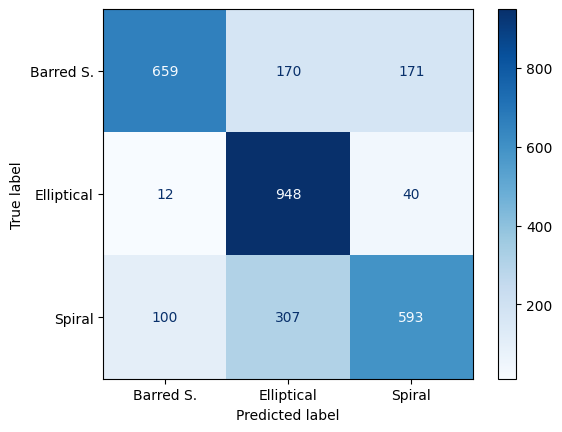


Epoch: 10
---------
Train loss: 0.6161, Train accuracy: 73.6776%

Test loss: 0.6136, Test accuracy: 73.3932%

[[701 157 142]
 [ 13 929  58]
 [154 273 573]]


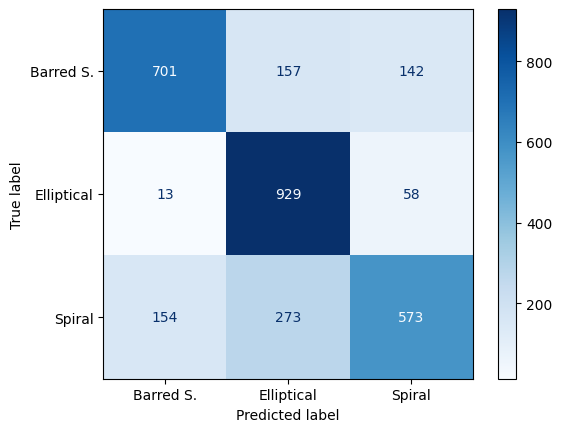


Epoch: 11
---------
Train loss: 0.6110, Train accuracy: 73.6340%

Test loss: 0.6151, Test accuracy: 74.0248%

[[654 175 171]
 [  8 949  43]
 [ 94 289 617]]


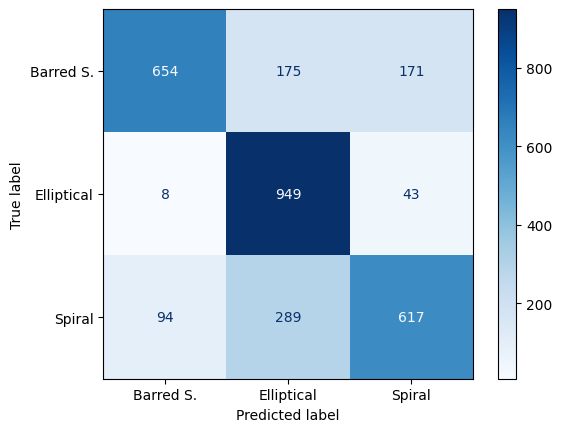


Epoch: 12
---------
Train loss: 0.5997, Train accuracy: 74.3214%

Test loss: 0.5883, Test accuracy: 75.0443%

[[699 108 193]
 [ 47 871  82]
 [113 206 681]]


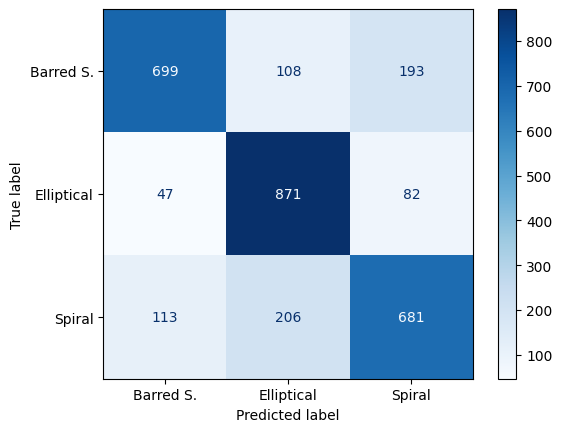


Epoch: 13
---------
Train loss: 0.5908, Train accuracy: 74.8528%

Test loss: 0.5809, Test accuracy: 74.3684%

[[707  95 198]
 [ 39 838 123]
 [133 180 687]]


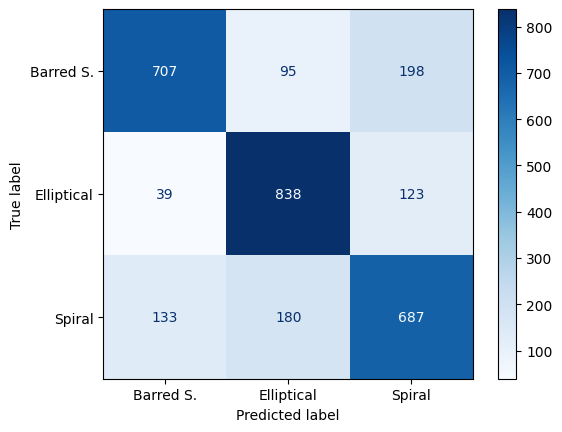


Epoch: 14
---------
Train loss: 0.5881, Train accuracy: 74.7680%

Test loss: 0.5818, Test accuracy: 74.8449%

[[687  98 215]
 [ 37 841 122]
 [109 175 716]]


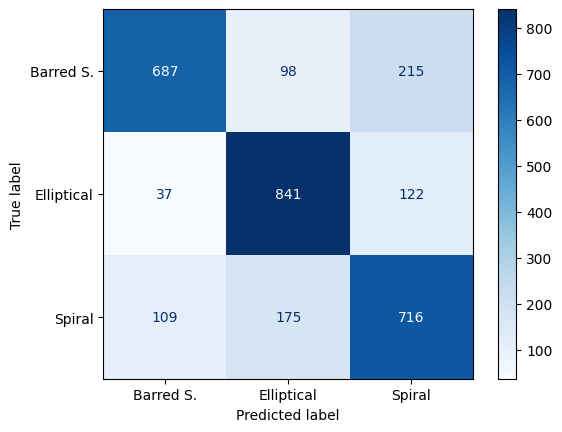


Epoch: 15
---------
Train loss: 0.5798, Train accuracy: 75.1996%

Test loss: 0.5843, Test accuracy: 74.2132%

[[710 109 181]
 [ 41 874  85]
 [135 222 643]]


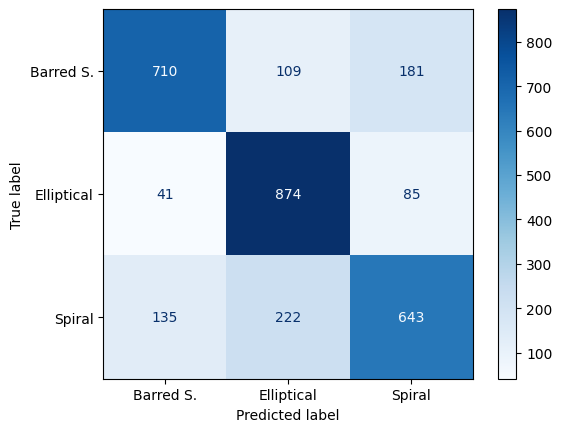


Epoch: 16
---------
Train loss: 0.5723, Train accuracy: 75.3381%

Test loss: 0.5718, Test accuracy: 75.5984%

[[663 126 211]
 [ 21 928  51]
 [ 80 243 677]]


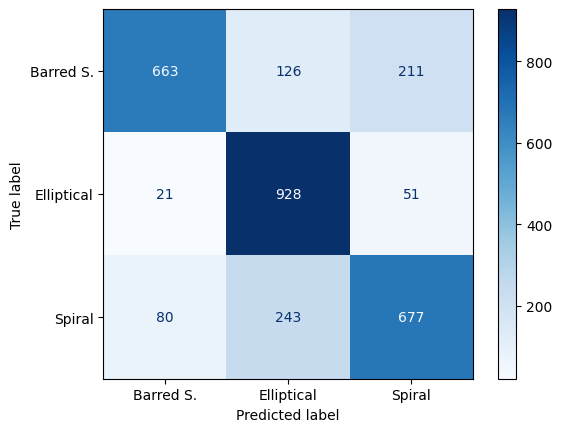


Epoch: 17
---------
Train loss: 0.5652, Train accuracy: 75.7735%

Test loss: 0.6093, Test accuracy: 74.6343%

[[647 122 231]
 [  9 885 106]
 [ 66 227 707]]


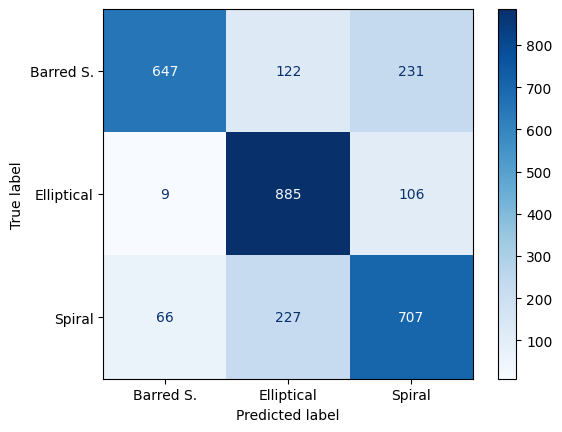


Epoch: 18
---------
Train loss: 0.5653, Train accuracy: 75.8870%

Test loss: 0.5915, Test accuracy: 74.5900%

[[670 110 220]
 [ 30 852 118]
 [ 95 189 716]]


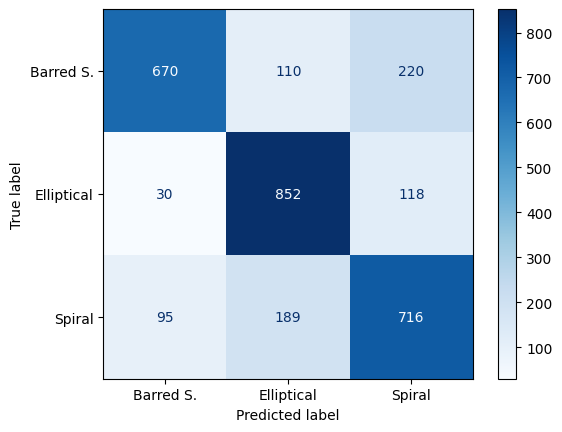


Epoch: 19
---------
Train loss: 0.5556, Train accuracy: 76.0579%

Test loss: 0.5756, Test accuracy: 75.2438%

[[774 107 119]
 [ 40 894  66]
 [194 216 590]]


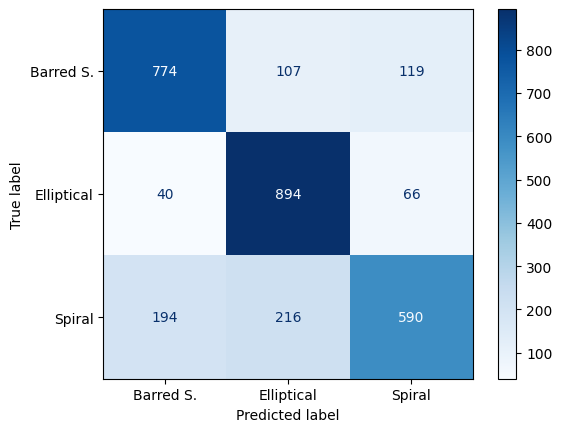


Epoch: 20
---------
Train loss: 0.5567, Train accuracy: 75.9494%

Test loss: 0.5830, Test accuracy: 74.4127%

[[671  84 245]
 [ 23 794 183]
 [ 90 143 767]]


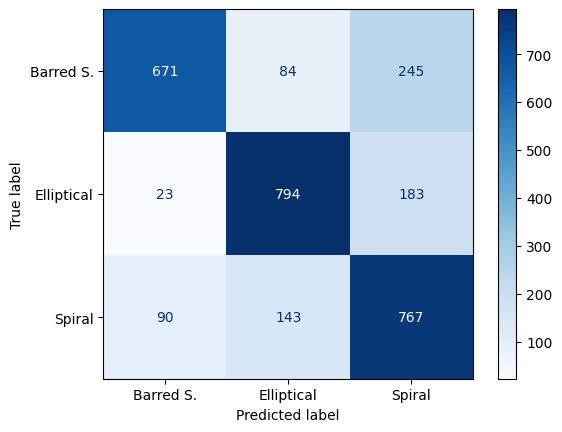


Epoch: 21
---------
Train loss: 0.5475, Train accuracy: 76.7041%

Test loss: 0.5697, Test accuracy: 75.2881%

[[755 115 130]
 [ 36 895  69]
 [170 222 608]]


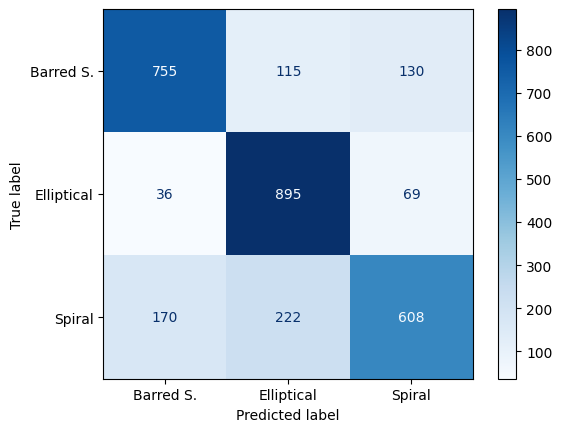


Epoch: 22
---------


KeyboardInterrupt: 

In [21]:
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)
#exactly what it says. Reduce learning rate on plateau

# will probably use this to plot a graph or something
results = {"train_loss": [],
           "train_acc": [],
           "test_loss": [],
           "test_acc": []}

for epoch in tqdm(range(1, 41)):
  print(f"\nEpoch: {epoch}\n---------")
  train_loss, train_acc = train()
  test_loss, test_acc = test()
  print(f"Train loss: {train_loss:0.4f}, Train accuracy: {train_acc * 100 :0.4f}%\n")
  print(f"Test loss: {test_loss:0.4f}, Test accuracy: {test_acc * 100 :0.4f}%\n")

  cm = confusion_matrix(all_targets, all_preds)
  all_targets = []
  all_preds = [] #resetting for next epoch
  print(cm)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Barred S.", "Elliptical", "Spiral"])
  disp.plot(cmap=plt.cm.Blues)
  plt.show()

  # scheduler.step(test_loss)#reduce lr if acc plateaus


  results["train_loss"].append(train_loss)
  results["train_acc"].append(train_acc)
  results["test_loss"].append(test_loss)
  results["test_acc"].append(test_acc)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

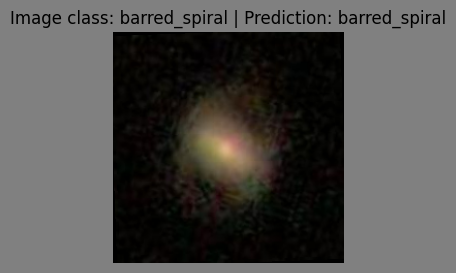

In [22]:
model.eval()
data, target = test_data[19] ###
output = model(data.to(device).unsqueeze(dim=0))
prediction = output.argmax(dim=1,keepdim=True).item()
img_as_array = np.asarray(data.permute(1, 2, 0))
plt.figure(figsize=(3, 3)).set_facecolor('grey')
plt.title(f"Image class: {class_names[target]} | Prediction: {class_names[prediction]}")
plt.imshow(img_as_array)
plt.axis(False)